# Bone Fracture Detection

---

## 2-Stage Model Logic
```
X-ray Image
     │
     ▼
┌─────────────────────────────┐
│  STAGE 1 — EfficientNet-B4  │   Binary Classification
│  Normal  vs  Fracture       │
└─────────────────────────────┘
     │
     ├──── Normal ──────────────► ✅ Output: NORMAL (stop here)
     │
     └──── Fracture ────────────►
                                  ┌─────────────────────────────┐
                                  │  STAGE 2 — ResNet50         │   Multi-Class
                                  │  Hairline  vs  Major Crack  │
                                  └─────────────────────────────┘
                                       │              │
                                       ▼              ▼
                                  🦴 Hairline    💥 Major Crack
```

## SET-UP

### Check GPU

In [1]:
import torch
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name   :', torch.cuda.get_device_name(0))
    print('VRAM       :', round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), 'GB')
else:
    print('⚠️  No GPU — go to Runtime → Change runtime type → T4 GPU')

GPU available: True
GPU name   : Tesla T4
VRAM       : 15.6 GB


In [2]:
# Patch num_workers in all dataloader calls
import torch
# Colab T4 has 2 CPU cores — use 2 workers max
NUM_WORKERS = 2

print(f"CPU cores available: {torch.get_num_threads()}")
print(f"Setting num_workers = {NUM_WORKERS}")

CPU cores available: 1
Setting num_workers = 2


### Install packages

In [4]:
!pip install -q timm==0.9.16 grad-cam==1.5.0 scikit-learn seaborn tqdm opencv-python
print('✅ Packages installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 18.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 100.9 MB/s eta 0:00:00
✅ Packages installed


### Set up project on  data dir

In [5]:
import os, zipfile, shutil

# Single variable for Drive location
DRIVE_PATH = '/content/drive/MyDrive/My Works/Bone facture'

# Navigate to the Drive folder
os.chdir(DRIVE_PATH)
print('✅ Working directory:', os.getcwd())

# ── 1. Extract stage1.zip to data folder ─────────────
s1_zip = f'{DRIVE_PATH}/stage1.zip'
data_folder = f'{DRIVE_PATH}/data'

if os.path.exists(s1_zip):
    print('\n📦 Extracting stage1.zip to data folder... (may take 1-2 min)')
    with zipfile.ZipFile(s1_zip, 'r') as z:
        z.extractall(data_folder)
    print('✅ stage1.zip extracted to data/')
else:
    print('❌ stage1.zip NOT FOUND')

# ── 2. Extract stage2.zip to data folder ─────────────
s2_zip = f'{DRIVE_PATH}/stage2.zip'

if os.path.exists(s2_zip):
    print('\n📦 Extracting stage2.zip to data folder...')
    with zipfile.ZipFile(s2_zip, 'r') as z:
        z.extractall(data_folder)
    print('✅ stage2.zip extracted to data/')
else:
    print('❌ stage2.zip NOT FOUND')

# ── 3. Verify contents ─────────────────────────────
print('\n📁 Contents of data folder:')
if os.path.exists(data_folder):
    print(os.listdir(data_folder))
else:
    print('❌ data folder not found')

print('\n✅ All files extracted. Ready to use!')

✅ Working directory: /content/drive/MyDrive/My Works/Bone facture
❌ stage1.zip NOT FOUND
❌ stage2.zip NOT FOUND

📁 Contents of data folder:
['stage2', 'stage1']

✅ All files extracted. Ready to use!


### Verify dataset & src files

In [6]:
DRIVE_PATH = '/content/drive/MyDrive/My Works/Bone facture'

# Navigate to the Drive folder
os.chdir(DRIVE_PATH)
print('✅ Working directory:', os.getcwd())

print('\n📁 Contents of data folder:')
if os.path.exists(data_folder):
    print(os.listdir(data_folder))
else:
    print('❌ data folder not found')

✅ Working directory: /content/drive/MyDrive/My Works/Bone facture

📁 Contents of data folder:
['stage2', 'stage1']


In [7]:
import os

def count_images(folder):
    ext = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
    total = 0
    if not os.path.exists(folder):
        print(f'  ⚠️  MISSING: {folder}')
        return 0
    for root, dirs, files in os.walk(folder):
        dirs.sort()
        n = sum(1 for f in files if os.path.splitext(f)[1].lower() in ext)
        if n > 0:
            rel = os.path.relpath(root, '.')
            print(f'  {rel:<52} {n:>5} imgs')
            total += n
    return total

print('── Stage 1 data ──────────────────────────────────────')
t1 = count_images('data/stage1')
print(f'   TOTAL: {t1}\n')

print('── Stage 2 data ──────────────────────────────────────')
t2 = count_images('data/stage2')
print(f'   TOTAL: {t2}\n')

print('── src/ scripts ──────────────────────────────────────')
if os.path.exists('src'):
    for f in sorted(os.listdir('src')):
        print(f'  src/{f}')
else:
    print('  ❌ src/ folder missing!')

── Stage 1 data ──────────────────────────────────────
  data/stage1/test/fracture                             1193 imgs
  data/stage1/test/normal                                505 imgs
  data/stage1/train/fracture                            4851 imgs
  data/stage1/train/normal                              2417 imgs
  data/stage1/val/fracture                              1172 imgs
  data/stage1/val/normal                                 519 imgs
   TOTAL: 10657

── Stage 2 data ──────────────────────────────────────
  data/stage2/test/hairline                               17 imgs
  data/stage2/test/major_crack                            48 imgs
  data/stage2/train/hairline                             674 imgs
  data/stage2/train/major_crack                         1939 imgs
  data/stage2/val/hairline                                17 imgs
  data/stage2/val/major_crack                             48 imgs
   TOTAL: 2743

── src/ scripts ──────────────────────────────────────
  src/__py

## Model

### Preview sample X-rays

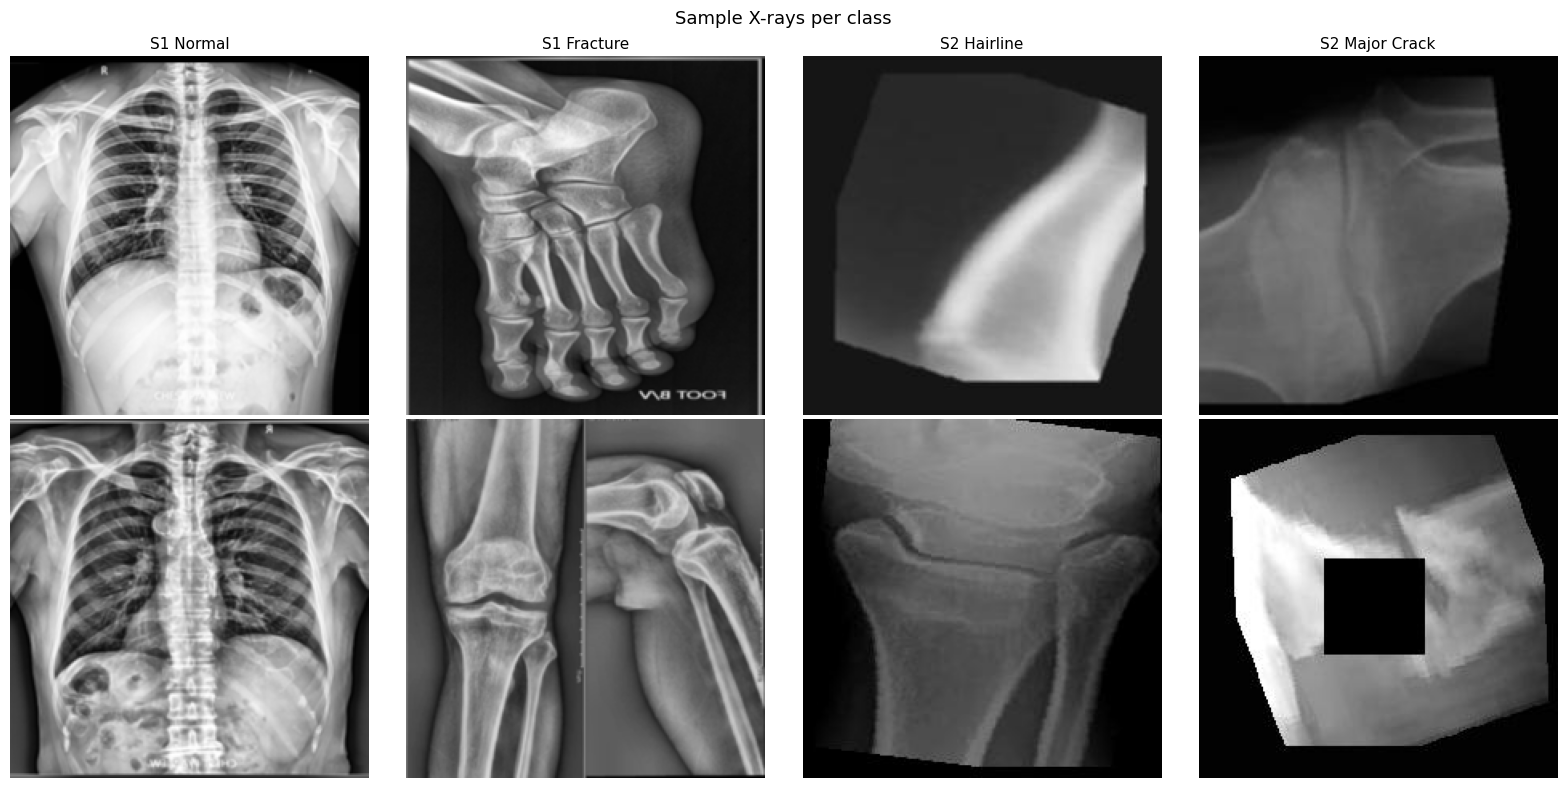

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import random, glob

classes = [
    ('data/stage1/train/normal',      'S1 Normal'),
    ('data/stage1/train/fracture',    'S1 Fracture'),
    ('data/stage2/train/hairline',    'S2 Hairline'),
    ('data/stage2/train/major_crack', 'S2 Major Crack'),
]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, (folder, label) in enumerate(classes):
    imgs = glob.glob(f'{folder}/*.jpg') + glob.glob(f'{folder}/*.png') + glob.glob(f'{folder}/*.jpeg')
    for row in range(2):
        ax = axes[row][col]
        if imgs:
            img = Image.open(random.choice(imgs)).convert('RGB').resize((224,224))
            ax.imshow(img)
            if row == 0: ax.set_title(label, fontsize=11)
        else:
            ax.text(0.5, 0.5, f'No images\n{folder}', ha='center', va='center',
                    color='red', fontsize=8, transform=ax.transAxes)
        ax.axis('off')
plt.suptitle('Sample X-rays per class', fontsize=13)
plt.tight_layout()
plt.show()

### Train Stage 1 (Normal vs Fracture)

In [9]:
# Run train_stage1.py inline — shows all output + errors
import runpy, os, sys

# Make sure we're in project root and src is on path
os.chdir('/content/drive/MyDrive/My Works/Bone facture')
if 'src' not in sys.path: sys.path.insert(0, 'src')

print('Starting Stage 1 training...')
print('Working dir:', os.getcwd())
print('-' * 50)

try:
    runpy.run_path('src/train_stage1.py', run_name='__main__')
    print('\n✅ Stage 1 training complete!')
except SystemExit as e:
    if e.code == 0:
        print('\n✅ Stage 1 training complete!')
    else:
        print(f'\n❌ Stage 1 exited with code {e.code}')
except Exception as e:
    import traceback
    print('\n❌ Stage 1 ERROR:')
    traceback.print_exc()

Starting Stage 1 training...
Working dir: /content/drive/MyDrive/My Works/Bone facture
--------------------------------------------------

  Stage 1 Training — Normal vs Fracture
  Device: cuda

  Stage 1 | train |  7,268 images | classes: {'fracture': 0, 'normal': 1}
  Stage 1 | val   |  1,691 images | classes: {'fracture': 0, 'normal': 1}
  Stage 1 | test  |  1,698 images | classes: {'fracture': 0, 'normal': 1}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

[Stage1 Model] EfficientNet-B4 | pretrained=True | freeze_backbone=True | trainable=13,109,818

Model loaded. Warming up head for 3 epochs...

Epoch 1/10 | Train Loss: 0.3209 Acc: 0.8806 | Val Loss: 0.4887 Acc: 0.8433 | LR: 0.001000 | 1047.9s
  ✓ Best model saved (val_acc=0.8433)
Epoch 2/10 | Train Loss: 0.2097 Acc: 0.9212 | Val Loss: 0.5535 Acc: 0.8545 | LR: 0.001000 | 371.2s
  ✓ Best model saved (val_acc=0.8545)
Epoch 3/10 | Train Loss: 0.1614 Acc: 0.9414 | Val Loss: 0.5842 Acc: 0.8664 | LR: 0.001000 | 247.8s
  ✓ Best model saved (val_acc=0.8664)

→ Unfreezing full backbone at epoch 4

[Stage1 Model] All 17,552,202 params unfrozen
Epoch 4/10 | Train Loss: 0.0984 Acc: 0.9652 | Val Loss: 0.5942 Acc: 0.8687 | LR: 0.000285 | 184.5s
  ✓ Best model saved (val_acc=0.8687)
Epoch 5/10 | Train Loss: 0.0731 Acc: 0.9748 | Val Loss: 0.6365 Acc: 0.8616 | LR: 0.000244 | 165.5s
Epoch 6/10 | Train Loss: 0.0528 Acc: 0.9809 | Val Loss: 0.6620 Acc: 0.8758 | LR: 0.000183 | 152.6s
  ✓ Best model saved (va

### Train Stage 2 (Hairline / Major Crack)

In [10]:
import runpy, os, sys

os.chdir('/content/drive/MyDrive/My Works/Bone facture')
if 'src' not in sys.path: sys.path.insert(0, 'src')

print('Starting Stage 2 training...')
print('Working dir:', os.getcwd())
print('-' * 50)

try:
    runpy.run_path('src/train_stage2.py', run_name='__main__')
    print('\n✅ Stage 2 training complete!')
except SystemExit as e:
    if e.code == 0:
        print('\n✅ Stage 2 training complete!')
    else:
        print(f'\n❌ Stage 2 exited with code {e.code}')
except Exception as e:
    import traceback
    print('\n❌ Stage 2 ERROR:')
    traceback.print_exc()

Starting Stage 2 training...
Working dir: /content/drive/MyDrive/My Works/Bone facture
--------------------------------------------------

  Stage 2 Training — Hairline vs Major Crack
  Device: cuda
  Class counts: {'hairline': 77, 'major_crack': 709}

  Stage 2 | train |  2,613 images | classes: {'hairline': 0, 'major_crack': 1}
  Stage 2 | val   |     65 images | classes: {'hairline': 0, 'major_crack': 1}
  Stage 2 | test  |     65 images | classes: {'hairline': 0, 'major_crack': 1}
[FocalLoss] class order (sorted): ['hairline', 'major_crack']
[FocalLoss] alpha weights: {'hairline': 1.804071307182312, 'major_crack': 0.19592876732349396}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 156MB/s]


[Stage2 Model] ResNet50 | trainable=525,058 | device=cpu

Model loaded. Warming up head for 5 epochs...



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 001/60 | Train Loss: 0.0369 F1: 0.3346 | Val Loss: 0.0279 F1: 0.2073 Acc: 0.2615 | 118.5s
    hairline             F1 = 0.4146
    major_crack          F1 = 0.0000
  ✓ Best model saved (macro_f1=0.2073)
Epoch 002/60 | Train Loss: 0.0270 F1: 0.3315 | Val Loss: 0.0277 F1: 0.2073 Acc: 0.2615 | 61.5s
    hairline             F1 = 0.4146
    major_crack          F1 = 0.0000
Epoch 003/60 | Train Loss: 0.0253 F1: 0.3386 | Val Loss: 0.0245 F1: 0.2073 Acc: 0.2615 | 39.0s
    hairline             F1 = 0.4146
    major_crack          F1 = 0.0000
Epoch 004/60 | Train Loss: 0.0257 F1: 0.3260 | Val Loss: 0.0247 F1: 0.2073 Acc: 0.2615 | 30.1s
    hairline             F1 = 0.4146
    major_crack          F1 = 0.0000
Epoch 005/60 | Train Loss: 0.0239 F1: 0.3338 | Val Loss: 0.0261 F1: 0.2073 Acc: 0.2615 | 29.0s
    hairline             F1 = 0.4146
    major_crack          F1 = 0.0000

→ Unfreezing full backbone at epoch 6

[Stage2 Model] All 24,033,090 params unfrozen
Epoch 006/60 | Train Loss: 0.

### Model Evaluation

In [11]:
import runpy, os, sys

os.chdir('/content/drive/MyDrive/My Works/Bone facture')
if 'src' not in sys.path: sys.path.insert(0, 'src')

print('Running evaluation...')
try:
    runpy.run_path('src/evaluate.py', run_name='__main__')
    print('\n✅ Evaluation complete!')
except SystemExit as e:
    if e.code == 0:
        print('\n✅ Evaluation complete!')
    else:
        print(f'\n❌ Evaluate exited with code {e.code}')
except Exception as e:
    import traceback
    print('\n❌ Evaluation ERROR:')
    traceback.print_exc()

Running evaluation...

  Evaluating Stage 1: Normal vs Fracture


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Stage 1 | train |  7,268 images | classes: {'fracture': 0, 'normal': 1}
  Stage 1 | val   |  1,691 images | classes: {'fracture': 0, 'normal': 1}
  Stage 1 | test  |  1,698 images | classes: {'fracture': 0, 'normal': 1}
[Stage1 Model] EfficientNet-B4 | pretrained=False | freeze_backbone=True | trainable=13,109,818
  Loaded checkpoint from epoch 10 (val_acc=0.8788)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  Classification Report:
              precision    recall  f1-score   support

      normal     0.9574    0.8474    0.8991      1193
    fracture     0.7165    0.9109    0.8021       505

    accuracy                         0.8663      1698
   macro avg     0.8369    0.8792    0.8506      1698
weighted avg     0.8857    0.8663    0.8702      1698

  AUROC: 0.9418
  Confusion matrix saved → src/../results/confusion_matrix_stage1.png
  ROC curve saved → src/../results/roc_stage1.png

  Evaluating Stage 2: Hairline vs Major Crack
  Stage 2 | train |  2,613 images | classes: {'hairline': 0, 'major_crack': 1}
  Stage 2 | val   |     65 images | classes: {'hairline': 0, 'major_crack': 1}
  Stage 2 | test  |     65 images | classes: {'hairline': 0, 'major_crack': 1}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Stage2 Model] ResNet50 | trainable=525,058 | device=cpu
  Loaded checkpoint from epoch 21 (val_f1=0.8241)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  Classification Report:
              precision    recall  f1-score   support

    hairline     0.5882    0.5882    0.5882        17
 major_crack     0.8542    0.8542    0.8542        48

    accuracy                         0.7846        65
   macro avg     0.7212    0.7212    0.7212        65
weighted avg     0.7846    0.7846    0.7846        65

  Confusion matrix saved → src/../results/confusion_matrix_stage2.png
  ROC curve saved → src/../results/roc_stage2.png

All evaluation results saved to results/


✅ Evaluation complete!


### Confusion matrices


confusion_matrix_stage1.png exists | size=60854 bytes
Image size: (2017, 731) | mode: RGBA



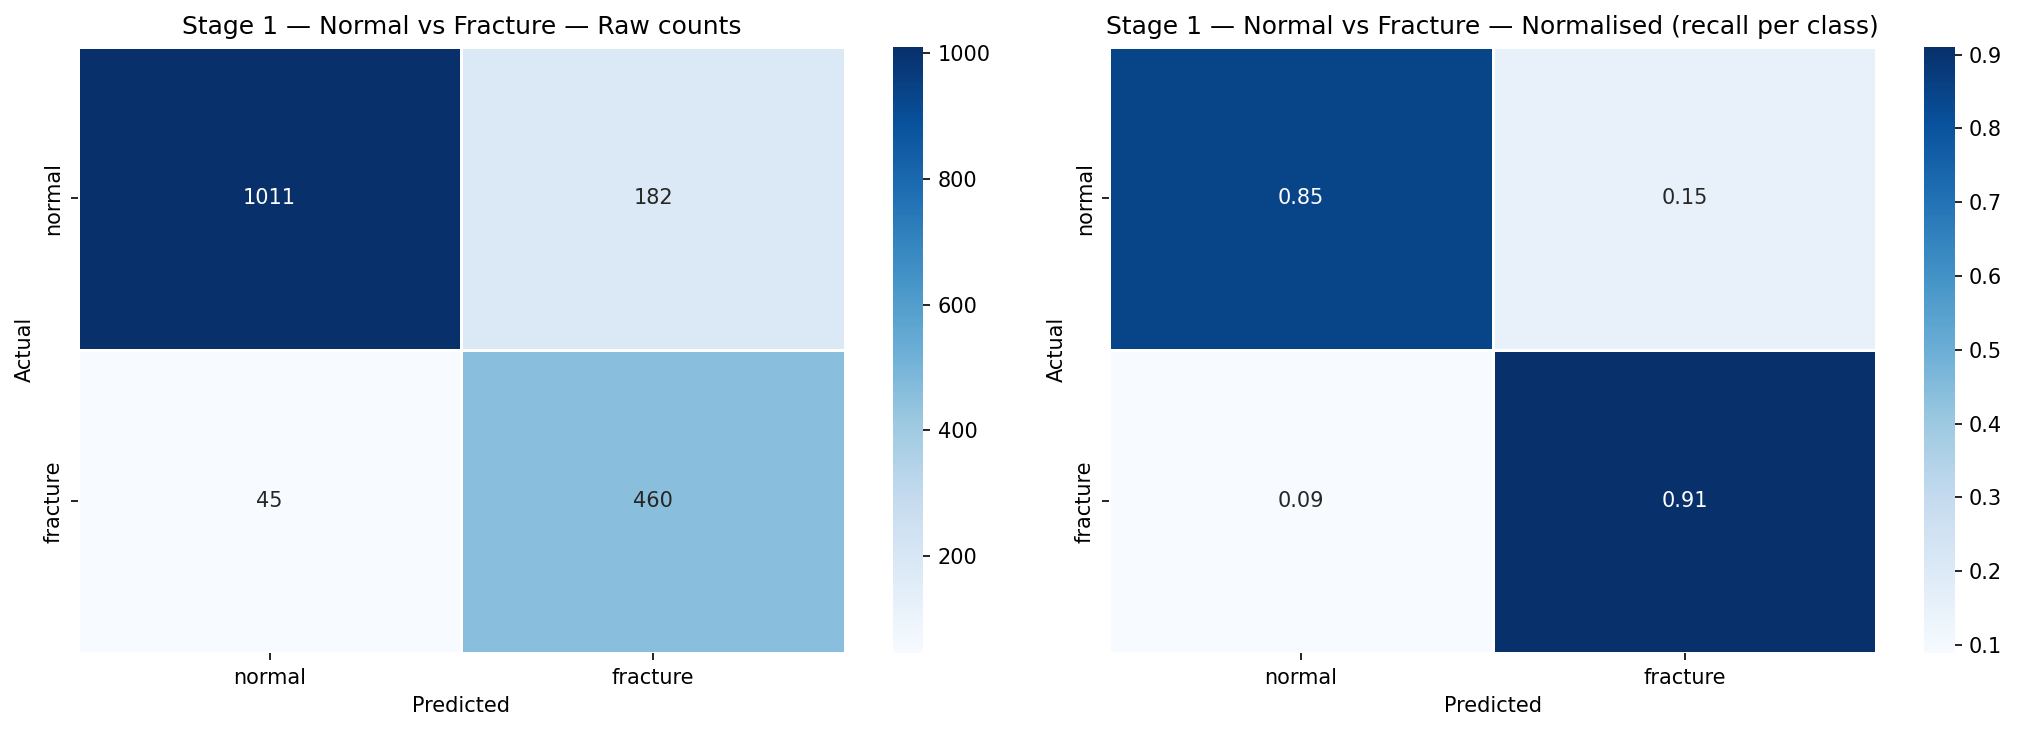


confusion_matrix_stage2.png exists | size=56320 bytes
Image size: (2016, 731) | mode: RGBA



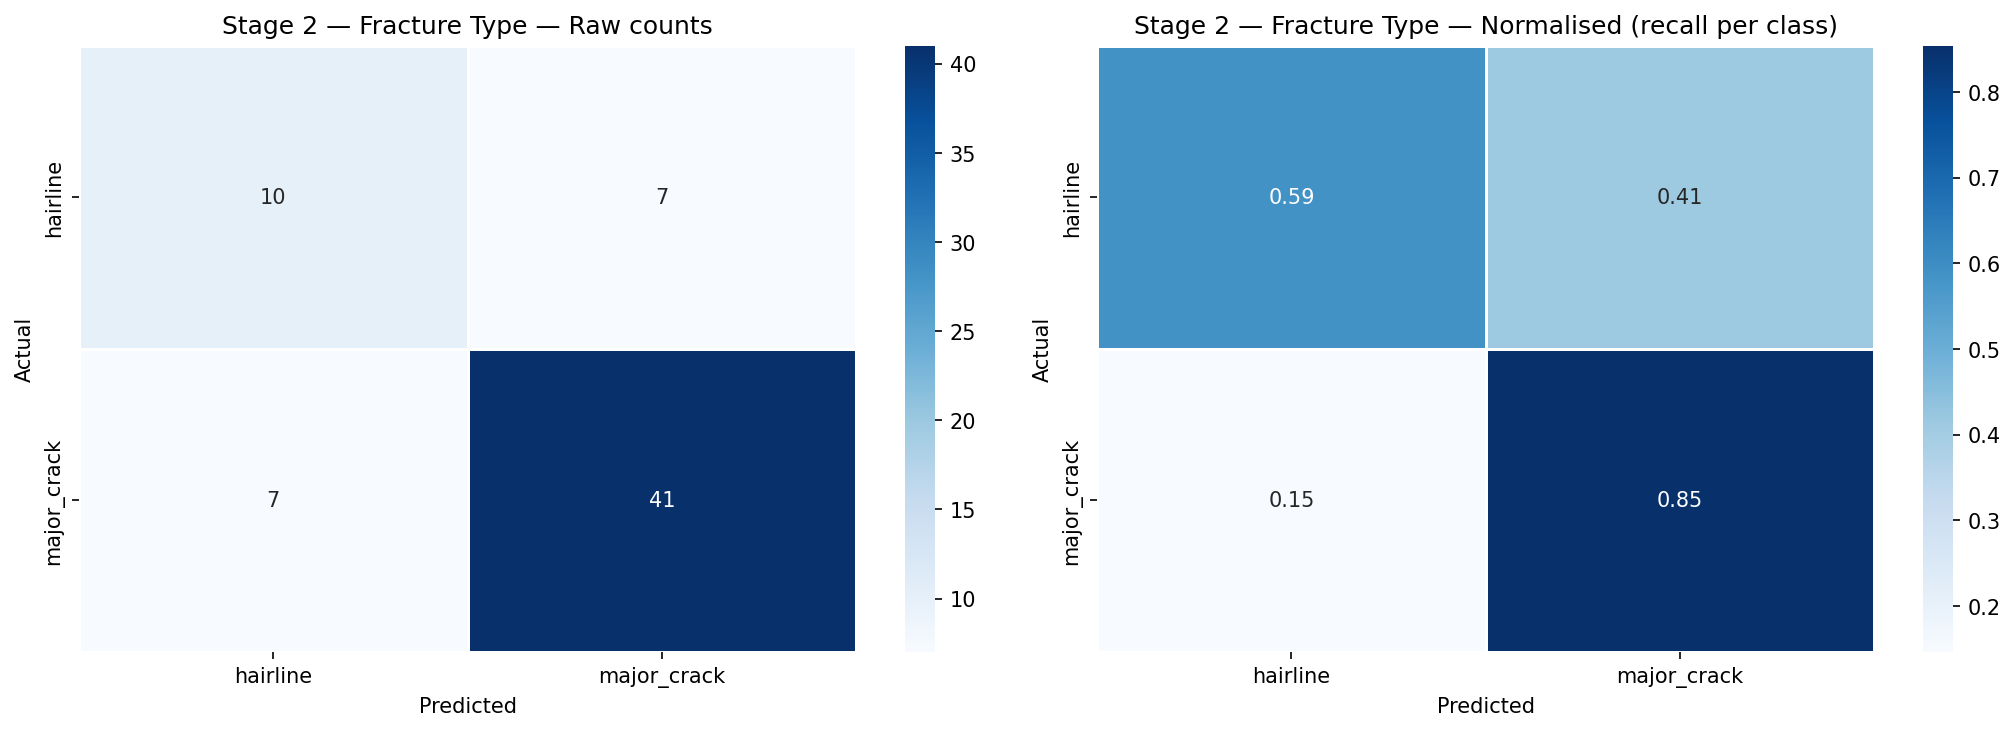

In [26]:
import os
from PIL import Image

BASE = '/content/drive/MyDrive/My Works/Bone facture'

for name in ['confusion_matrix_stage1.png', 'confusion_matrix_stage2.png']:
    path = f'{BASE}/results/{name}'
    if os.path.exists(path):
        size = os.path.getsize(path)
        print(f"\n{name} exists | size={size} bytes")
        img = Image.open(path)
        print(f"Image size: {img.size} | mode: {img.mode}\n")
        display(img)

### ROC Curve

Not found: roc_curve_stage1.png
Showing: roc_stage1.png


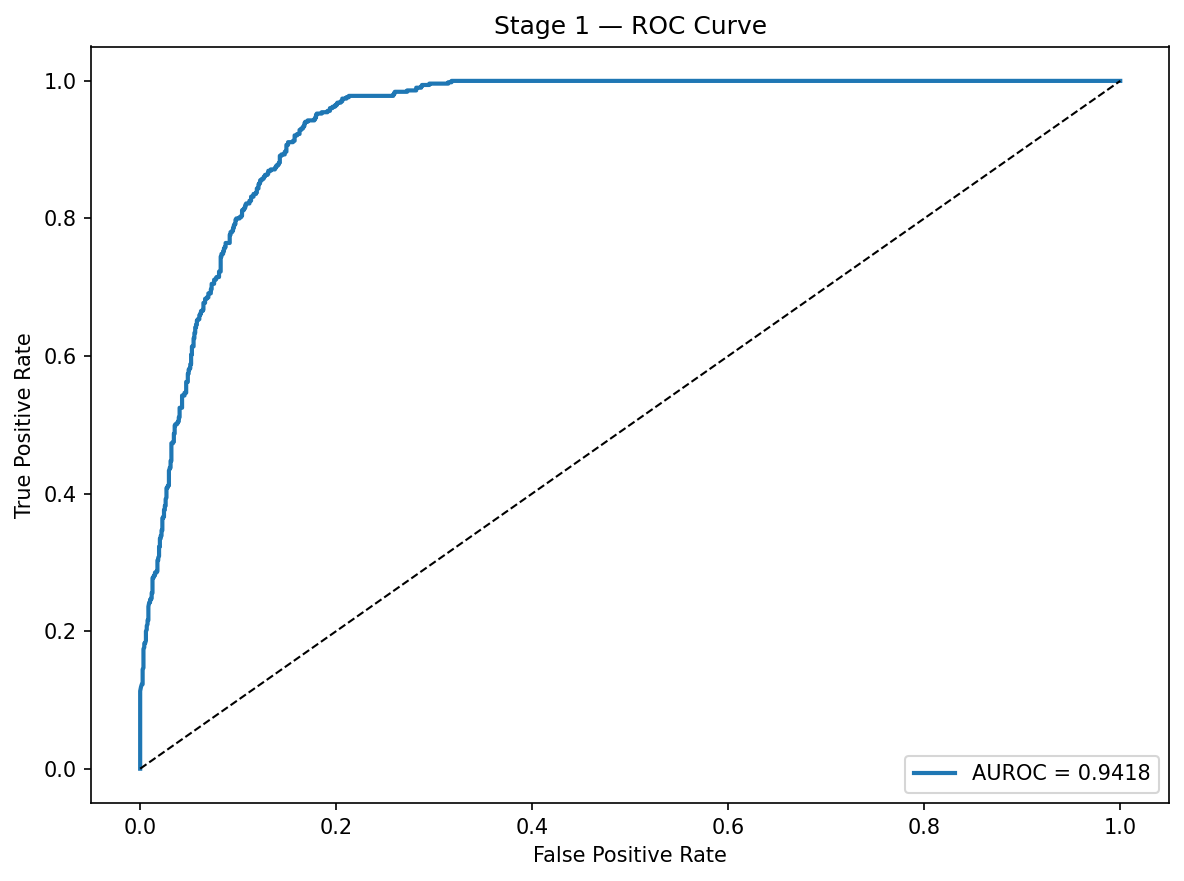

Showing: roc_stage2.png


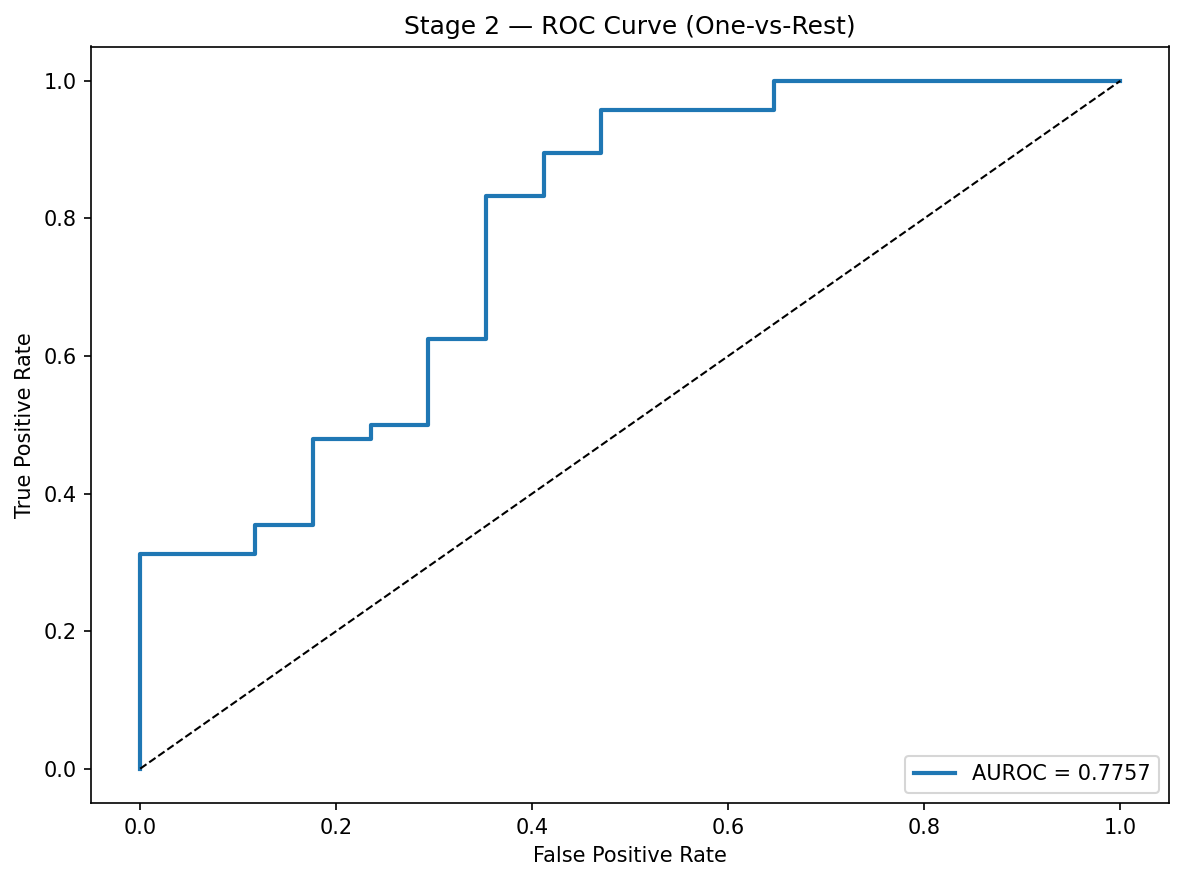

In [13]:
from IPython.display import Image as IPImage
import os

BASE = '/content/drive/MyDrive/My Works/Bone facture'

# Try both filenames (evaluate.py saves as roc_stage1.png)
for fname in ['roc_curve_stage1.png', 'roc_stage1.png', 'roc_stage2.png']:
    path = f'{BASE}/results/{fname}'
    if os.path.exists(path):
        print(f'Showing: {fname}')
        display(IPImage(path, width=600))
    else:
        print(f'Not found: {fname}')

## Testing  on a single image

In [18]:
import os, sys, torch, glob
from PIL import Image
import torchvision.transforms as T

os.chdir('/content/drive/MyDrive/My Works/Bone facture')
if 'src' not in sys.path: sys.path.insert(0, 'src')

# ── Hardcode since classes not saved in checkpoint ───────
s1_classes = ['fracture', 'normal']   # ImageFolder sorts alphabetically
s2_classes = ['hairline', 'major_crack']
fracture_idx = 0   # 'fracture' comes before 'normal' alphabetically

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Load Stage 1 ─────────────────────────────────────────
from model_stage1 import build_stage1_model
ckpt1  = torch.load('checkpoints/model1_best.pth', map_location=device)
model1 = build_stage1_model(pretrained=False, freeze_backbone=False, device=device)
model1.load_state_dict(ckpt1['model_state'])
model1.eval()
print(f"✅ Stage 1 loaded | epoch={ckpt1.get('epoch')}")

# ── Load Stage 2 ─────────────────────────────────────────
from model_stage2 import build_stage2_model
ckpt2  = torch.load('checkpoints/model2_best.pth', map_location=device)
model2 = build_stage2_model(num_classes=2, pretrained=False,   # hardcode 2
                             freeze_backbone=False, device=device)
model2.load_state_dict(ckpt2['model_state'])
model2.eval()
print(f"✅ Stage 2 loaded | epoch={ckpt2.get('epoch')}")

# ── Transform ────────────────────────────────────────────
tfm = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ── 2-Stage cascade function ─────────────────────────────
THRESHOLD = 0.40

def predict(image_path):
    img = tfm(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)

    with torch.no_grad():
        s1_probs     = torch.softmax(model1(img), dim=1)[0]
    fracture_prob    = s1_probs[fracture_idx].item()
    is_fracture      = fracture_prob >= THRESHOLD

    if not is_fracture:
        return f"NORMAL  (conf={1-fracture_prob:.3f})"

    with torch.no_grad():
        s2_probs = torch.softmax(model2(img), dim=1)[0]
    s2_pred  = s2_probs.argmax().item()
    s2_label = s2_classes[s2_pred]
    s2_conf  = s2_probs[s2_pred].item()
    return f"FRACTURE → {s2_label.upper()}  (s1={fracture_prob:.3f}  s2={s2_conf:.3f})"

# ── Test on fracture + normal images ─────────────────────
print(f"\n── Testing (threshold={THRESHOLD}) ──────────────────")

test_fracture = (glob.glob('data/stage1/test/fracture/*.png') +
                 glob.glob('data/stage1/test/fracture/*.jpg'))[:5]
test_normal   = (glob.glob('data/stage1/test/normal/*.png') +
                 glob.glob('data/stage1/test/normal/*.jpg'))[:3]

print("\nFRACTURE images (should show FRACTURE → hairline or major_crack):")
for p in test_fracture:
    true = 'fracture'
    pred = predict(p)
    ok   = '✅' if 'FRACTURE' in pred else '❌'
    print(f"  {ok} {os.path.basename(p)[:40]:40s} → {pred}")

print("\nNORMAL images (should show NORMAL):")
for p in test_normal:
    pred = predict(p)
    ok   = '✅' if 'NORMAL' in pred else '❌'
    print(f"  {ok} {os.path.basename(p)[:40]:40s} → {pred}")


[Stage1 Model] EfficientNet-B4 | pretrained=False | freeze_backbone=False | trainable=17,552,202
✅ Stage 1 loaded | epoch=10
[Stage2 Model] ResNet50 | trainable=24,033,090 | device=cuda
✅ Stage 2 loaded | epoch=21

── Testing (threshold=0.4) ──────────────────

FRACTURE images (should show FRACTURE → hairline or major_crack):
  ✅ 1454_rt_foot_b_v_rt_foot_b_v_major_bony_ → FRACTURE → HAIRLINE  (s1=1.000  s2=0.556)
  ✅ 1220_lumber_spine_b_v_lumber_spine_b_v_s → FRACTURE → MAJOR_CRACK  (s1=1.000  s2=0.716)
  ✅ 1301_lumber_spine_b_v_lumber_spine_b_v_s → FRACTURE → HAIRLINE  (s1=1.000  s2=0.702)
  ✅ 1238_lumber_spine_b_v_lumber_spine_b_v_s → FRACTURE → HAIRLINE  (s1=1.000  s2=0.613)
  ✅ 1426_dorso_lumber_spine_b_v_dorso_lumber → FRACTURE → HAIRLINE  (s1=1.000  s2=0.740)

NORMAL images (should show NORMAL):
  ✅ 1296_CHEST_P_A_VIEW_CHEST_P_A_VIEW_norma → NORMAL  (conf=1.000)
  ✅ 1035_Chest_P_A_Adult_Chest_P_A_Adult_nor → NORMAL  (conf=1.000)
  ✅ 1361_PNS_PNS_normal_1_Rotation.png       → NORM